In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits

In [31]:
X = torch.linspace(-1, 1, 50).reshape(-1, 1); y = 2 * X + 1

model = nn.Linear(1 , 1)
loss_fn = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))
for step in range(200):
    pred = model(X)
    loss = loss_fn(pred, y)
    optimizer.zero_grad()
    loss.backward()
    print(f"at step :{step} loss:{loss}")

    optimizer.step()
print(model.weight.item(), model.bias.item())

# single layer neural network in step loop

at step :0 loss:3.0139455795288086
at step :1 loss:3.010652542114258
at step :2 loss:3.007361650466919
at step :3 loss:3.0040740966796875
at step :4 loss:3.000789165496826
at step :5 loss:2.997507333755493
at step :6 loss:2.9942281246185303
at step :7 loss:2.990952253341675
at step :8 loss:2.9876794815063477
at step :9 loss:2.9844095706939697
at step :10 loss:2.981142520904541
at step :11 loss:2.9778788089752197
at step :12 loss:2.9746181964874268
at step :13 loss:2.9713613986968994
at step :14 loss:2.968107223510742
at step :15 loss:2.9648568630218506
at step :16 loss:2.9616096019744873
at step :17 loss:2.9583654403686523
at step :18 loss:2.955125093460083
at step :19 loss:2.951887845993042
at step :20 loss:2.9486541748046875
at step :21 loss:2.9454240798950195
at step :22 loss:2.942197799682617
at step :23 loss:2.9389748573303223
at step :24 loss:2.935755729675293
at step :25 loss:2.932539939880371
at step :26 loss:2.9293277263641357
at step :27 loss:2.926119089126587
at step :28 los

In [48]:
digits = load_digits()
X, y = digits.data, digits.target
Xtr,Xte,ytr,yte = train_test_split(X, y, test_size = 0.25,
                                   random_state = 42, stratify= y)
# sc = StandardScaler().fit(Xtr)
Xtr = torch.tensor(sc.transform(Xtr), dtype = torch.float32)
ytr = torch.tensor(ytr, dtype = torch.long)
Xte = torch.tensor(sc.transform(Xte), dtype=torch.float32)
yte = torch.tensor(yte, dtype = torch.long)

model = nn.Sequential(
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Linear(32,16),
    nn.ReLU(),
    nn.Linear(16,10),
)
loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.05)
loss_tensor = []
for epoch in range(200):
    pred = model(Xtr)
    loss = loss_fn(pred, ytr)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_tensor.append(loss)
    print(f"epoch:{epoch} loss:{loss.mean()}")

with torch.no_grad():
    acc = (model(Xte).argmax(1) == yte).float().mean()


epoch:0 loss:2.323760747909546
epoch:1 loss:2.072377920150757
epoch:2 loss:1.6003180742263794
epoch:3 loss:1.0925673246383667
epoch:4 loss:0.7292540669441223
epoch:5 loss:0.5054319500923157
epoch:6 loss:0.3615402281284332
epoch:7 loss:0.3056900203227997
epoch:8 loss:0.20330911874771118
epoch:9 loss:0.15741004049777985
epoch:10 loss:0.1346634030342102
epoch:11 loss:0.09720122814178467
epoch:12 loss:0.07163175940513611
epoch:13 loss:0.06428172439336777
epoch:14 loss:0.05383968725800514
epoch:15 loss:0.035221364349126816
epoch:16 loss:0.025099674239754677
epoch:17 loss:0.023544026538729668
epoch:18 loss:0.018600203096866608
epoch:19 loss:0.012077532708644867
epoch:20 loss:0.009608305059373379
epoch:21 loss:0.008974537253379822
epoch:22 loss:0.007378371432423592
epoch:23 loss:0.0051210722886025906
epoch:24 loss:0.0034664212726056576
epoch:25 loss:0.0027479929849505424
epoch:26 loss:0.002279609674587846
epoch:27 loss:0.0018076271517202258
epoch:28 loss:0.0013436268782243133
epoch:29 loss:0.

In [49]:
from matplotlib import pyplot as  plt
import numpy as np
loss_numpy = []

for i in loss_tensor:
    loss_numpy.append(i.detach().numpy())

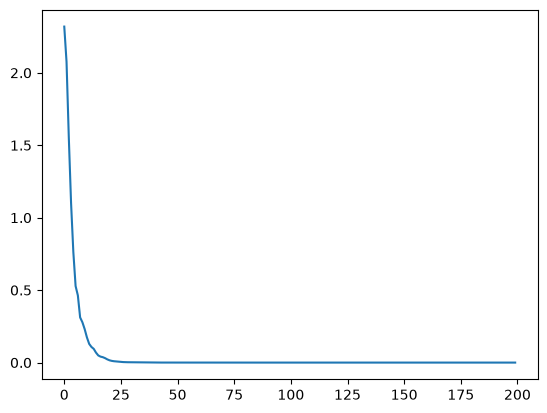

In [45]:
plt.plot(np.arange(200),loss_numpy)